[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 53s 23ms/step - accuracy: 0.8393 - loss: 0.3335 - val_accuracy: 0.9377 - val_loss: 0.1588
Epoch 2/3
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9271 - loss: 0.1823 - val_accuracy: 0.9412 - val_loss: 0.1461
Epoch 3/3
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.9313 - loss: 0.1747 - val_accuracy: 0.9424 - val_loss: 0.1541

Оцінка моделі на тестових даних
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step


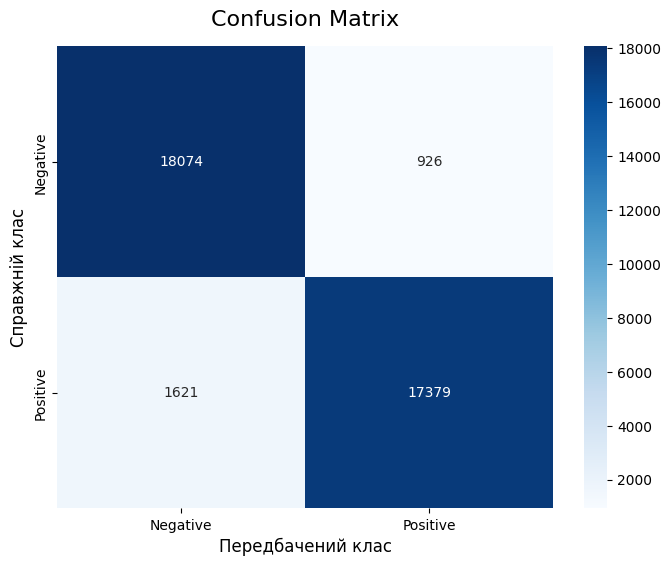

Accuracy: 0.9330
Precision: 0.9494
Recall: 0.9147
F-Score: 0.9317

1. Текст з навчального датасету
Текст: Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply ...
Справжній клас: Negative
Передбачений клас: Negative (Ймовірність: 0.0239)

2. Власні тексти

Приклад 1:
Текст: 'The food was absolutely disgusting. The meat was undercooked and the service was terrible. I will never go back there.'
Аналіз: Negative (Ймовірність: 0.0062)

Приклад 2:
Текст: 'I really enjoyed my visit! The atmosphere is cozy, the coffee is great and the staff is incredibly friendly.'
Аналіз: Positive (Ймовірність: 0.9959)

Приклад 3:
Текст: 'It was just okay. Not the best I've had, but certainly not the worst. Mediocre experience overall.'
Аналіз: Negative (Ймовірність: 0.0372)


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import seaborn as sns
import matplotlib.pyplot as plt

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

train_path = '/content/drive/MyDrive/NN/dataset/train.csv'
test_path = '/content/drive/MyDrive/NN/dataset/test.csv'

train_df = pd.read_csv(train_path, names=['label', 'text'])
test_df = pd.read_csv(test_path, names=['label', 'text'])

train_df['label'] = train_df['label'] - 1
test_df['label'] = test_df['label'] - 1

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train_df['clean_text'])

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_text']), maxlen=max_len, padding='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_text']), maxlen=max_len, padding='post')

y_train = train_df['label'].values
y_test = test_df['label'].values

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=True),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_train_pad, y_train,
    epochs=3,
    batch_size=256,
    validation_split=0.1
)

print("\nОцінка моделі на тестових даних")
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

conf_matrix = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive']
            )

plt.title('Confusion Matrix', fontsize=16, pad=15)
plt.xlabel('Передбачений клас', fontsize=12)
plt.ylabel('Справжній клас', fontsize=12)
plt.show()

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F-Score: {f1:.4f}")

def analyze_sentiment(input_text):
    cleaned = preprocess_text(input_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')
    prob = model.predict(padded, verbose=0)[0][0]
    return "Positive" if prob > 0.5 else "Negative", prob


sample_index = 0
sample_train_text = train_df['text'].iloc[sample_index]
true_label = "Positive" if train_df['label'].iloc[sample_index] == 1 else "Negative"
predicted_label, prob = analyze_sentiment(sample_train_text)

print("\n1. Текст з навчального датасету")
print(f"Текст: {sample_train_text[:200]}...")
print(f"Справжній клас: {true_label}")
print(f"Передбачений клас: {predicted_label} (Ймовірність: {prob:.4f})")

custom_texts = [
    "The food was absolutely disgusting. The meat was undercooked and the service was terrible. I will never go back there.",
    "I really enjoyed my visit! The atmosphere is cozy, the coffee is great and the staff is incredibly friendly.",
    "It was just okay. Not the best I've had, but certainly not the worst. Mediocre experience overall."
]

print("\n2. Власні тексти")
for i, text in enumerate(custom_texts, 1):
    sentiment, prob = analyze_sentiment(text)
    print(f"\nПриклад {i}:")
    print(f"Текст: '{text}'")
    print(f"Аналіз: {sentiment} (Ймовірність: {prob:.4f})")